
<div style="border:solid green 2px; padding: 20px">

👋 **¡Hola! Soy Dot, tu revisor de IA.**

He completado la primera revisión de tu código. A continuación, encontrarás mis comentarios y sugerencias de mejora.

**¿Qué debes hacer ahora?**

1. **Revisar:** Lee mis comentarios en el notebook más abajo.
2. **Decidir:**
* **¿Estás de acuerdo con el feedback?** ¡Genial! Actualiza tu código según las sugerencias.
* **¿No estás de acuerdo o crees que es un error?** ¡No hay problema! Puedes dejar tu código exactamente como está.


3. **Volver a enviar:** Envía tu proyecto de nuevo. **Tu próxima iteración será revisada por un experto humano**, independientemente de si hiciste cambios o no.

-------------------------------------------------------------------------------------------------------------
Mis comentarios están más abajo. **Te pido amablemente que no los muevas, modifiques ni elimines**.

Verás mis comentarios resaltados en cuadros verdes, amarillos o rojos como estos:

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Correcto. Todo se ha hecho exitosamente.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones.
</div>



# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

En primer lugar, instalaremos las librerías necesarias para el desarrollo de todo el proyecto. En segundo lugar, cargaremos cada archivo por separado, con el fin de conservar la integridad de los datos, tener mayor flexibilidad en el análisis y asegurar eficiencia al no duplicar información sin ser necesario; asimismo, se añade el parámetro sep= el cual nos permite especificar el separador ';' con el cual vienen los archivos .csv. Finalmente, se aplica el método .info() a cada DataFrame para observar el número de columnas, filas y tipos de datos. 

In [5]:
# importar librerías
import pandas as pd # nos permite manipular y procesar los datos
from matplotlib import pyplot as plt # nos permite crear y visualizar gráficas

In [6]:
# Primero cargar cada archivo por separado
df_instacart_orders = pd.read_csv('C:\\Users\\celyn\\OneDrive\\Escritorio\\Proyecto 3\\Data\\instacart_orders.csv', sep=';')
df_products = pd.read_csv('C:\\Users\\celyn\\OneDrive\\Escritorio\\Proyecto 3\\Data\\products.csv', sep=';')
df_aisles = pd.read_csv('C:\\Users\\celyn\\OneDrive\\Escritorio\\Proyecto 3\\Data\\aisles.csv', sep=';') 
df_departments = pd.read_csv('C:\\Users\\celyn\\OneDrive\\Escritorio\\Proyecto 3\\Data\\departments.csv', sep=';')
df_order_products = pd.read_csv('C:\\Users\\celyn\\OneDrive\\Escritorio\\Proyecto 3\\Data\\order_products.csv', sep=';')

In [7]:
# mostrar información del DataFrame
df_instacart_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [8]:
# mostrar información del DataFrame
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [9]:
# mostrar información del DataFrame
df_aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [10]:
df_departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


In [11]:
df_order_products.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Conclusiones

Podemos denotar por cada df que:

- df_instacart_orders: 6 columnas (478,967 filas)

- df_products: 4 columnas (49,694 filas)

- df_aisles: 2 columnas (134 filas)

- df_departments: 2 columnas (21 filas)

- df_order_products: 4 columnas (4,545,007 filas) - ¡el más grande!

Asimismo, podemos reslatar algunos puntos clave que necesitarán tratamiento especial:

1. Valores ausentes detectados:
   

   - days_since_prior_order: 28,819 valores faltantes

   - product_name: 1,258 valores faltantes

   - add_to_cart_order: 836 valores faltantes
   
3. Tipos de datos: Algunos están como float64 cuando podrían ser enteros

Finalmente, podemos observar que hay columnas que conectan las tablas, siendo:

- order_id
- product_id
- department_id
- aisle_id

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

El Paso 1 está bien completado: cargaste los datasets con el separador correcto, usaste `show_counts=True` donde fue útil, y tu resumen señala claramente las columnas clave con valores faltantes y las consideraciones de tipos de datos (datatype) que deberías abordar a continuación.<br>
</div>

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Para empezar, vamos a identificar y eliminar los valores duplicados. Luego, vamos a identificar y completar los valores ausentes.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

Para comenzar, vamos a encontrar el total de filas completamente duplicadas en el DataFrame:

In [12]:
print(f"Total de filas duplicadas: {df_instacart_orders.duplicated().sum()}")

Total de filas duplicadas: 15


El resultado quiere decir que hay 15 pedidos que aparecen exactamente duplicados. 

In [13]:
# Revisa si hay pedidos duplicados (duplicados explícitos)
duplicated_orders = df_instacart_orders[df_instacart_orders.duplicated()].head()
print(f"Características de las órdenes duplicadas: {duplicated_orders}")

Características de las órdenes duplicadas:         order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   

        days_since_prior_order  
145574                     2.0  
223105                    30.0  
230807                    16.0  
266232                     NaN  
273805                     6.0  


Podemos observar que las filas duplicadas del DataFrame tienen el día miércoles como día de la semana en que se hizo un pedido, y las 2:00 AM como la hora del día en que se hizo el pedido. Esto significa que hay 15 pedidos que aparecen exactamente duplicados, todos hechos los miércoles a las 2:00 AM.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Al investigar los casos de “miércoles a las 2:00 a. m.”, sería más claro filtrar e inspeccionar directamente ese subconjunto combinado en este punto, en lugar de calcular “2 a. m.” y “miércoles” por separado primero.<br>
</div>

In [14]:
# Filtrar todos los pedidos del miércoles (order_dow = 3) a las 2:00 AM (order_hour_of_day = 2)
wednesday_2am_orders = df_instacart_orders[(df_instacart_orders['order_dow'] == 3) & 
                                          (df_instacart_orders['order_hour_of_day'] == 2)]

print(f"Total de pedidos el miércoles a las 2:00 AM: {len(wednesday_2am_orders)}")
print("\nPrimeros 10 pedidos:")
print(wednesday_2am_orders.head(10))

Total de pedidos el miércoles a las 2:00 AM: 121

Primeros 10 pedidos:
       order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838    2766110   162084            41          3                  2   
5156    2190225   138285            18          3                  2   
15506    553049    58599            13          3                  2   
18420    382357   120200            19          3                  2   
24691    690242    77357             2          3                  2   
25376   1378085    75705            21          3                  2   
26301   2846262   176827             2          3                  2   
29129    353088    46038             4          3                  2   
30371   1918001   188546            14          3                  2   
31404   1725788   147843            10          3                  2   

       days_since_prior_order  
4838                     16.0  
5156                     11.0  
15506                     7.0  
18420   

Podemos observar que existen 121 pedidos el míercoles a las 2:00 AM, siendo 15 de ellos duplicados. 

In [15]:
# Pedidos por cliente en miércoles a las 2:00 AM
pedidos_por_cliente = wednesday_2am_orders.groupby('user_id').size()
print("Distribución de pedidos por cliente en miércoles 2:00 AM:")
print(pedidos_por_cliente.describe())

Distribución de pedidos por cliente en miércoles 2:00 AM:
count    106.000000
mean       1.141509
std        0.350202
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
dtype: float64


Podemos observar que en la franja horaria el comportamiento no presenta ninguna anomalía en términos de número de veces que el cliente ha hecho un pedido, siendo 2 pedidos máximo. 

**HIPÓTESIS:** Podemos observar que la cantidad de pedidos realizados en la franja horaria en donde se encuentran los valores duplicados es notablemente baja respecto a la cantidad total de pedidos del día, es decir, es una franja horaria atípica y poco significativa en términos de cantidad de órdenes ejecutadas por los clientes. Dado que la proporción de pedidos duplicados respecto al total de pedidos hechos durante el día y la hora analizadas también es significativamente baja y que la cantidad de pedidos realizados por cliente se comporta de una forma razonable, podemos sugerir que existe una falla técnica en el sistema de Instacart el cual está duplicando órdenes realizadas en este día y horario específicos. 

<div class="alert alert-block alert-danger">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Hay una inconsistencia en los cálculos de la hipótesis: algunas proporciones mezclan conteos de distintos subconjuntos (p. ej., 2 a.m. en general vs Wednesday en general vs Wednesday a las 2 a.m.). Vuelve a calcular las proporciones usando un único denominador consistente para que la conclusión no sea engañosa.<br>
</div>

In [16]:
# Elimina los pedidos duplicados
# Contar cuántos pedidos únicos vs duplicados hay
df_instacart_orders = df_instacart_orders.drop_duplicates()
print(f"Pedidos únicos: {len(df_instacart_orders)}")

Pedidos únicos: 478952


In [17]:
# Vuelve a verificar si hay filas duplicadas
print(f"Valores duplicados: {df_instacart_orders.duplicated().sum()}")

Valores duplicados: 0


In [18]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
print(f"IDs duplicados de pedidos: {df_instacart_orders['order_id'].duplicated().sum()}")

IDs duplicados de pedidos: 0


En primer lugar, se verificó la cantidad de filas duplicadas para luego observar las características de una muestra usando el método .head(). Luego, se encontró la cantidad de pedidos hechos a las 2:00 AM y la cantidad de pedidos hechos el día miércoles para encontrar la proporción de pedidos hechos en la hora respecto al día. Después, se juntaron las dos condiciones para hallar la cantidad de pedidos hechos en el día y la hora, lo que nos permitió observar que la muestra es relativamente pequeña respecto al total de órdenes. Finalmente, se intentó encontrar algún patrón en la cantidad de órdenes por usuario dentro de la franja horaria, sin obtener ningún patrón claro. En resumen, el análisis nos permite observar que los datos del día y la hora se pueden considerar atípicos y con poca influencia en el comportamiento del consumidor, pero con una oportunidad de mejora para Instacart y sus sistemas de información. 

### `products` data frame

In [19]:
df_products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [20]:
# Verifica si hay filas totalmente duplicadas
print(f"Filas totalmente duplicadas: {df_products.duplicated().sum()}")

Filas totalmente duplicadas: 0


In [21]:
# Revisa únicamente si hay ID de productos duplicados
print(f"IDs de productos duplicados: {df_products['product_id'].duplicated().sum()}")

IDs de productos duplicados: 0


In [22]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
nombres_mayusculas = df_products['product_name'].str.upper()
print(f"Nombres duplicados de productos: {nombres_mayusculas.duplicated().sum()}")

Nombres duplicados de productos: 1361


In [23]:
# Revisa si hay nombres duplicados de productos no faltantes
productos_con_nombre = df_products[df_products['product_name'].notna()] # Filtrar primero los productos con nombres no faltantes
nombres_mayusculas = productos_con_nombre['product_name'].str.upper()
print(f"Nombres duplicados de productos (solo no faltantes): {nombres_mayusculas.duplicated().sum()}")

Nombres duplicados de productos (solo no faltantes): 104


In [24]:
# Lista depurada de candidatos a duplicados
posibles_duplicados = df_products[
    df_products['product_name'].notna() & 
    df_products['product_name'].str.upper().duplicated()
].sort_values(by=['product_name','aisle_id','department_id'])

print(f"Posibles duplicados: {posibles_duplicados}")

Posibles duplicados:        product_id                               product_name  aisle_id  \
31844       31845  18-In-1 Hemp Peppermint Pure-Castile Soap        25   
19941       19942            Aged Balsamic Vinegar Of Modena        19   
24830       24831         Albacore Solid White Tuna in Water        95   
9037         9038                     American Cheese slices        21   
49530       49531               Anchovy Fillets In Olive Oil        95   
...           ...                                        ...       ...   
16990       16991                         Vitamin D3 2000 Iu        47   
49442       49443                         Vitamin D3 5000 Iu        47   
40093       40094              Wild Sardines In Spring Water        95   
38260       38261           Yams Cut Sweet Potatoes In Syrup        81   
12820       12821                              pumpkin spice        53   

       department_id  
31844             11  
19941             13  
24830             15 

En la revisión del catálogo de productos se confirmó que no existen filas totalmente duplicadas ni identificadores repetidos, lo que asegura la integridad de la llave primaria; sin embargo, se identificaron **104 registros con nombres de producto coincidentes** que, aunque mantienen `product_id` únicos, representan posibles duplicados semánticos. Entre ellos aparecen casos como *“18-In-1 Hemp Peppermint Pure-Castile Soap”*, *“Aged Balsamic Vinegar Of Modena”*, *“American Cheese slices”*, *“Vitamin D3 2000 IU”* y *“pumpkin spice”*, todos con pares de IDs distintos pero asociados a las mismas categorías de pasillo y departamento. Estos hallazgos sugieren que algunos productos podrían estar duplicados por error de carga, mientras que otros reflejan variaciones legítimas dentro del catálogo.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Describes la generación de un informe o el marcado de nombres de productos duplicados sospechosos, pero el notebook no muestra código ni salida que realmente cree dicho informe (o que añada una marca/flag o columna). Considera incluir la implementación (o indicar explícitamente que solo estás identificando candidatos, no modificando la tabla).<br>
</div>

### `departments` data frame

In [25]:
df_departments.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [26]:
# Revisa si hay filas totalmente duplicadas
department_duplicates = df_departments.duplicated().sum()
print(f"Filas totalmente duplicadas: {department_duplicates}")

Filas totalmente duplicadas: 0


In [27]:
# Revisa únicamente si hay IDs duplicadas de departamentos
print(f"IDs de departamentos duplicados: {df_departments['department_id'].duplicated().sum()}")

IDs de departamentos duplicados: 0


In [28]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras minúsculas para compararlos mejor)
nombres_mayusculas_departments = df_departments['department'].str.lower()
print(f"Nombres duplicados de productos: {nombres_mayusculas_departments.duplicated().sum()}")

Nombres duplicados de productos: 0


In [29]:
# Revisa si hay nombres duplicados de productos no faltantes
productos_con_nombre_departments = df_departments[df_departments['department'].notna()] # Filtrar primero los productos con nombres no faltantes
nombres_mayusculas_departments = productos_con_nombre_departments['department'].str.strip().str.lower()
print(f"Nombres duplicados de productos (solo no faltantes): {nombres_mayusculas_departments.duplicated().sum()}")

Nombres duplicados de productos (solo no faltantes): 0


En la revisión del dataframe de departamentos se comprobó que no existen filas totalmente duplicadas ni identificadores repetidos, lo que garantiza la integridad de la llave primaria. Además, al normalizar los nombres —convirtiéndolos a minúsculas y eliminando espacios en blanco— se verificó que tampoco hay coincidencias ocultas o duplicados semánticos. En consecuencia, el catálogo de 21 departamentos se encuentra limpio y consistente, sin necesidad de ajustes adicionales más allá de esta validación preventiva.

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Buena validación en `departments`: comprobaste filas totalmente duplicadas e IDs duplicados, y también normalizaste el texto (lower/strip) para detectar duplicados ocultos. Tu explicación escrita coincide con lo que calculaste.<br>
</div>

### `aisles` data frame

<div class="alert alert-block alert-warning">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Sí ejecutas más adelante las comprobaciones de duplicados de `aisles`, así que esta nota es solo sobre la estructura: considera colocar el código de verificación de duplicados inmediatamente en esta sección para que la narrativa y las comprobaciones requeridas sean más fáciles de seguir en un solo bloque.<br>
</div>

In [30]:
# Revisa si hay filas totalmente duplicadas
print(f"Filas totalmente duplicadas: {df_aisles.duplicated().sum()}")

Filas totalmente duplicadas: 0


In [31]:
# Revisa únicamente si hay IDs duplicadas de pasillos
print(f"IDs duplicadas de pasillos: {df_aisles['aisle_id'].duplicated().sum()}")

IDs duplicadas de pasillos: 0


In [32]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras minúsculas para compararlos mejor)
nombres_mayusculas_aisles = df_aisles['aisle'].str.lower()
print(f"Nombres duplicados de productos: {nombres_mayusculas_aisles.duplicated().sum()}")

Nombres duplicados de productos: 0


In [33]:
# Revisa si hay nombres duplicados de productos no faltantes
productos_con_nombre_aisles = df_aisles[df_aisles['aisle'].notna()] # Filtrar primero los productos con nombres no faltantes
nombres_mayusculas_aisles = productos_con_nombre_aisles['aisle'].str.strip().str.lower()
print(f"Nombres duplicados de productos (solo no faltantes): {nombres_mayusculas_aisles.duplicated().sum()}")

Nombres duplicados de productos (solo no faltantes): 0


En la revisión del dataframe de pasillos se comprobó que no existen filas totalmente duplicadas ni identificadores repetidos, lo que asegura la integridad de la llave primaria. Además, al normalizar los nombres —convirtiéndolos a minúsculas y eliminando espacios en blanco— se verificó que tampoco hay coincidencias ocultas o duplicados semánticos. En consecuencia, el catálogo de 134 pasillos se encuentra limpio y consistente, sin necesidad de ajustes adicionales más allá de esta validación preventiva.

### `order_products` data frame

<div class="alert alert-block alert-warning">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

El análisis de duplicados para `order_products` se completa más adelante (incluyendo la verificación de duplicados en combinaciones relevantes de columnas). Para mejorar la legibilidad, considera iniciar ese análisis directamente aquí en lugar de repetir primero la salida de `.head()`.<br>
</div>

In [34]:
df_order_products.describe()

,order_id,product_id,add_to_cart_order,reordered
count,4.545007e+06,4.545007e+06,4.544171e+06,4.545007e+06
mean,1.711166e+06,2.558084e+04,8.351669e+00,5.905025e-01
std,9.850955e+05,1.409552e+04,7.080368e+00,4.917411e-01
min,4.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,8.608170e+05,1.353500e+04,3.000000e+00,0.000000e+00
50%,1.711530e+06,2.527200e+04,6.000000e+00,1.000000e+00
75%,2.561311e+06,3.793500e+04,1.100000e+01,1.000000e+00
max,3.421079e+06,4.969400e+04,6.400000e+01,1.000000e+00


In [35]:
# Revisa si hay filas totalmente duplicadas
print(f"Filas totalmente duplicadas: {df_order_products.duplicated().sum()}")

Filas totalmente duplicadas: 0


In [36]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
print(f"IDs duplicadas de órdenes: {df_order_products['order_id'].duplicated().sum()}")

IDs duplicadas de órdenes: 4094961


In [37]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
print(f"IDs duplicadas de productos: {df_order_products['product_id'].duplicated().sum()}")

IDs duplicadas de productos: 4499434


In [38]:
# Duplicados reales
print(f"Duplicados reales: {df_order_products.duplicated(subset=['order_id','product_id']).sum()}")

Duplicados reales: 0


En la revisión del dataframe de órdenes y productos se comprobó que no existen filas totalmente duplicadas, lo que garantiza que cada registro es único en su conjunto de columnas. Sin embargo, se observó que los identificadores de órdenes y de productos aparecen repetidos miles de veces, lo cual no representa un error sino la naturaleza propia del dataset: una misma orden puede contener varios productos y un mismo producto puede estar presente en múltiples órdenes. La verdadera clave de integridad está en la combinación `(order_id, product_id)`, que asegura que no se registre dos veces el mismo producto dentro de la misma orden. Con esta validación, el proceso de limpieza se centró en eliminar únicamente duplicados reales de esa combinación y en revisar los valores faltantes de la columna `add_to_cart_order`, manteniendo así un catálogo confiable para posteriores análisis.


## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [39]:
# Encuentra los valores ausentes en la columna 'product_name'
df_products['product_name'].isna().sum()

np.int64(1258)

In [40]:
df_products['product_name'].value_counts(dropna=False)

product_name
NaN                                                                  1258
Smart Ones Classic Favorites Mini Rigatoni With Vodka Cream Sauce       1
Green Chile Anytime Sauce                                               1
Porto                                                                   1
Small & Medium Dental Dog Treats                                        1
                                                                     ... 
HIGH PERFORMANCE ENERGY DRINK                                           1
ORIGINAL PANCAKE & WAFFLE MIX                                           1
ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR                         1
SPRING WATER BODY WASH                                                  1
Robust Golden Unsweetened Oolong Tea                                    1
Name: count, Length: 48437, dtype: int64

In [41]:
no_product_name = df_products[df_products['product_name'].isna()]
print(no_product_name)

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Podemos observar que existen un total de 1258 valores faltantes en la columna `product_name`, cuya notación aparece como `NaN`.

In [42]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
aisle_100 = (no_product_name['aisle_id'] == 100).all()
print(f"¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100? {aisle_100}")

¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100? True


In [43]:
print(f"Valores únicos de aisle_id en productos sin nombre: {no_product_name['aisle_id'].unique()}")

Valores únicos de aisle_id en productos sin nombre: [100]


Podemos confirmar que todos los nombres de productos ausentes `product_name` están relacionados con el pasillo con ID 100.

In [44]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
aisle_100 = (no_product_name['department_id'] == 21).all()
print(f"¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21? {aisle_100}")

¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21? True


In [45]:
print(f"Valores únicos de department_id en productos sin nombre: {no_product_name['department_id'].unique()}")

Valores únicos de department_id en productos sin nombre: [21]


Podemos confirmar que todos los nombres de productos ausentes `product_name` están relacionados con el departamento con ID 21.

In [46]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.

# Revisar información del pasillo con ID 100
pasillo_100 = df_aisles[df_aisles['aisle_id'] == 100]
print("Información del pasillo con ID 100:")
print(pasillo_100)

Información del pasillo con ID 100:
    aisle_id    aisle
99       100  missing


In [47]:
# Revisar información del departamento con ID 21
departamento_21 = df_departments[df_departments['department_id'] == 21]
print("Información del departamento con ID 21:")
print(departamento_21)

Información del departamento con ID 21:
    department_id department
20             21    missing


In [48]:
# Ver cuántos productos hay en total en este pasillo y departamento
productos_pasillo_100 = df_products[df_products['aisle_id'] == 100]
productos_departamento_21 = df_products[df_products['department_id'] == 21]

print(f"Total de productos en pasillo 100: {len(productos_pasillo_100)}")
print(f"Total de productos en departamento 21: {len(productos_departamento_21)}")
print(f"Productos sin nombre en pasillo 100: {productos_pasillo_100['product_name'].isna().sum()}")

Total de productos en pasillo 100: 1258
Total de productos en departamento 21: 1258
Productos sin nombre en pasillo 100: 1258


Esta información es crucial porque nos revela que estos productos no tienen nombres faltantes por error o casualidad. En realidad, están intencionalmente marcados como "missing" en el sistema de Instacart. Esto puede significar que para el pasillo y departamento de víveres la categoría está incompleta.

In [49]:
# Completa los nombres de productos ausentes con 'Unknown'
df_products['product_name'].fillna('Unknown',inplace=True)

In [50]:
# Verificación de reemplazo
df_products['product_name'].isna().sum()

np.int64(0)

In [51]:
# Visualización de reemplazo
unknown_replace = df_products['product_name'].isna()
print(unknown_replace)

0        False
1        False
2        False
3        False
4        False
         ...  
49689    False
49690    False
49691    False
49692    False
49693    False
Name: product_name, Length: 49694, dtype: bool


En el análisis de la columna **`product_name`** se identificaron **1,258 valores ausentes**, todos concentrados en el **pasillo con ID 100** y el **departamento con ID 21**, los cuales están etiquetados como *“missing”* en sus respectivas tablas de referencia. Esto indica que la ausencia de nombres no es aleatoria, sino que corresponde a una categoría incompleta del catálogo. Para garantizar la consistencia del dataset y evitar problemas en futuros análisis, se reemplazaron los valores faltantes con la etiqueta **“Unknown”**, logrando que la columna quede sin registros nulos y manteniendo la integridad del dataframe.


<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Buen trabajo: identificaste valores faltantes de `product_name`, verificaste que todos se asignan al pasillo 100 y al departamento 21 usando las tablas de referencia, y luego imputaste un marcador de posición claro (`Unknown`) con un paso de verificación.<br>
</div>

### `orders` data frame

In [52]:
# Encuentra los valores ausentes
df_instacart_orders.isna().sum()

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

<div class="alert alert-block alert-warning">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Concluyes que `days_since_prior_order` falta solo en los primeros pedidos y que piensas mantener esos NaNs, pero la sección del notebook está planteada como “identificar y rellenar valores faltantes”. Haz explícita la decisión como una estrategia intencional de no imputación y menciona brevemente cómo manejarás estos NaNs en análisis posteriores (p. ej., al graficar o al agregar).<br>
</div>

In [53]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?

faltantes = df_instacart_orders[df_instacart_orders['days_since_prior_order'].isna()]

# Revisar si todos corresponden al primer pedido
print(faltantes['order_number'].unique())

[1]


En la revisión de la columna **`days_since_prior_order`** se identificaron **28,817 valores ausentes**, y al analizarlos se confirmó que todos corresponden al **primer pedido de cada cliente** (donde `order_number = 1`). Esto significa que los valores nulos no representan un error de carga, sino la lógica natural del dataset: en el primer pedido no existe una orden previa con la cual calcular los días transcurridos.

**Decisión de no imputación:** Se ha decidido **mantener deliberadamente estos valores NaN** sin reemplazarlos ni eliminarlos, ya que representan información válida (la ausencia de un pedido previo) y son inherentes a la estructura de los datos.

**Manejo de NaNs en análisis posteriores:**
- **Al filtrar/segmentar datos:** Los valores NaN serán excluidos automáticamente cuando se analicen métricas relacionadas con el tiempo entre pedidos (ej. `df[df['days_since_prior_order'].notna()]`)
- **Al graficar:** Se utilizarán métodos como `.dropna()` para evitar errores en visualizaciones cuando sea necesario
- **Al calcular agregaciones:** Se emplearán funciones que ignoren NaNs por defecto (como `.mean()`, `.median()`) o se usará el parámetro `skipna=True` explícitamente cuando se trabaje con esta columna.

### `order_products` data frame

<div class="alert alert-block alert-warning">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Esta sección inicia la investigación de valores faltantes en `add_to_cart_order`; considera comenzar con el subconjunto específico de filas/pedidos con valores faltantes (guardando los `order_id` afectados) en lugar de volver a repetir la salida de `head()`.<br>
</div>

In [54]:
# Encuentra los valores ausentes
df_order_products.isna().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [55]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?

# Valor máximo
valor_maximo = df_order_products['add_to_cart_order'].max()
print(f"El valor máximo de la columna add_to_cart_order es: {valor_maximo}")

El valor máximo de la columna add_to_cart_order es: 64.0


In [56]:
# Valor mínimo
valores_minimo = df_order_products['add_to_cart_order'].min()
print(f"El valor máximo de la columna add_to_cart_order es: {valores_minimo}")

El valor máximo de la columna add_to_cart_order es: 1.0


En la revisión de la columna **`add_to_cart_order`** se identificaron **836 valores ausentes**, lo que indica que en algunos registros no quedó registrado el orden en que el producto fue agregado al carrito. Al analizar los valores válidos, se encontró que el mínimo es **1.0** y el máximo es **64.0**, lo que refleja la posición relativa de los productos dentro de una misma orden: el primero agregado corresponde al valor 1 y el último puede llegar hasta 64. Con estos hallazgos, la limpieza de datos debe enfocarse en decidir cómo tratar los valores faltantes —ya sea imputándolos con un valor por defecto, manteniéndolos como `NaN` o eliminando esas filas según el objetivo del análisis—, mientras que los valores existentes muestran un rango consistente y lógico dentro del proceso de compra.


In [57]:
# Se guardan todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'

pedidos_con_valores_ausentes = df_order_products[df_order_products['add_to_cart_order'].isna()]['order_id']

print(f"Número de registros con valores ausentes: {len(pedidos_con_valores_ausentes)}")
print(f"Número de pedidos únicos con valores ausentes: {pedidos_con_valores_ausentes.nunique()}")
print(f"Primeras 10 IDs de pedidos con valores ausentes:")
print(pedidos_con_valores_ausentes.head(10).tolist())

Número de registros con valores ausentes: 836
Número de pedidos únicos con valores ausentes: 70
Primeras 10 IDs de pedidos con valores ausentes:
[2449164, 1968313, 2926893, 1717990, 1959075, 844733, 61355, 936852, 264710, 1717990]


In [58]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?

# Se cuenta el número de productos en cada pedido
pedidos_con_ausentes_conteo = df_order_products[df_order_products['order_id'].isin(pedidos_con_valores_ausentes)].groupby('order_id').size()

print(f"Estadísticas de productos por pedido con valores ausentes:")
print(pedidos_con_ausentes_conteo.describe())

# Se revisa el valor mínimo del conteo
valor_minimo_productos = pedidos_con_ausentes_conteo.min()
print(f"Número mínimo de productos en pedidos con valores ausentes: {valor_minimo_productos}")

# Se verifica si todos tienen más de 64 productos
todos_mas_de_64 = (pedidos_con_ausentes_conteo > 64).all()
print(f"¿Todos los pedidos con valores ausentes tienen más de 64 productos? {todos_mas_de_64}")

Estadísticas de productos por pedido con valores ausentes:
count     70.000000
mean      75.942857
std       12.898585
min       65.000000
25%       67.000000
50%       71.000000
75%       78.000000
max      127.000000
dtype: float64
Número mínimo de productos en pedidos con valores ausentes: 65
¿Todos los pedidos con valores ausentes tienen más de 64 productos? True


In [59]:
# Se agrupa todos los pedidos con datos ausentes por su ID de pedido
pedidos_agrupados = df_order_products[df_order_products['add_to_cart_order'].isna()].groupby('order_id').size()
print(f"Pedidos con datos ausentes por su ID de pedido: {pedidos_agrupados}")

Pedidos con datos ausentes por su ID de pedido: order_id
9310        1
61355      63
102236     31
129627      5
165801      6
           ..
2999801     6
3125735    22
3308010    51
3347453     7
3383594     5
Length: 70, dtype: int64


In [60]:
# Se cuenta el número de 'product_id' en cada pedido y se revisa el valor mínimo del conteo.
productos_por_pedido = df_order_products.groupby('order_id').size()

print(f"Estadísticas de productos por pedido:")
print(productos_por_pedido.describe())

print(f"\nValor mínimo de productos por pedido: {productos_por_pedido.min()}")

# Ejemplos
print(f"\nPrimeros 10 pedidos y su cantidad de productos:")
print(productos_por_pedido.head(10))

Estadísticas de productos por pedido:
count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
dtype: float64

Valor mínimo de productos por pedido: 1

Primeros 10 pedidos y su cantidad de productos:
order_id
4     13
9     15
11     5
19     3
20     8
31    10
48     8
56    10
61    12
68     9
dtype: int64


En el análisis de la columna **`add_to_cart_order`** se identificaron **836 registros con valores ausentes**, distribuidos en **70 pedidos únicos**. Al revisar estos casos se encontró que todos corresponden a órdenes con más de **64 productos**, lo cual excede el rango máximo observado en la columna (1 a 64). En promedio, estos pedidos contienen alrededor de **76 productos**, con un mínimo de 65 y un máximo de 127. Esto sugiere que los valores faltantes no son errores aleatorios, sino que están asociados a órdenes de gran tamaño donde el campo no logró registrar la secuencia completa de adiciones al carrito. En contraste, el resto de pedidos del dataset muestra una distribución normal con un promedio cercano a 10 productos por orden y un mínimo de 1, confirmando que la ausencia de datos está concentrada únicamente en casos excepcionales de pedidos muy grandes. Los `NaN` en **`add_to_cart_order`** no son aleatorios: están directamente ligados al límite máximo observado de 64. La hipótesis más fuerte es que el sistema tenía un tope de registro en 64 productos por orden, y cualquier producto adicional quedó sin valor en esa columna.



In [61]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
df_order_products['add_to_cart_order'] = df_order_products['add_to_cart_order'].fillna(999).astype(int)
print(df_order_products['add_to_cart_order'])

0          17
1           1
2           1
3          35
4           5
           ..
4545002    12
4545003     9
4545004     4
4545005     8
4545006     9
Name: add_to_cart_order, Length: 4545007, dtype: int64


En la revisión de la columna **`add_to_cart_order`** se identificaron **836 valores ausentes**, todos asociados a pedidos con más de 64 productos. Para mantener la consistencia del dataset y evitar problemas en cálculos posteriores, estos valores se reemplazaron con el código **999**, que funciona como marcador explícito de “sin orden registrado”. Posteriormente, la columna fue convertida al tipo entero, asegurando que todos los registros tengan un valor válido y homogéneo para análisis futuros.


## Conclusiones

En el **Paso 2 de Preprocesamiento de los datos** se realizaron diversas validaciones y limpiezas que permiten asegurar la integridad del catálogo y la consistencia de las tablas de órdenes:  

- En las tablas de **departamentos** y **pasillos** se confirmó que no existen filas duplicadas ni identificadores repetidos, y que los nombres están normalizados sin espacios ocultos ni variaciones de mayúsculas/minúsculas.  
- En la tabla de **productos** se detectaron **1,258 valores ausentes en `product_name`**, todos concentrados en el pasillo y departamento etiquetados como *missing*. Estos fueron reemplazados por la etiqueta **“Unknown”** para mantener la completitud del dataset.  
- En la tabla de **órdenes y productos** se verificó que no hay filas totalmente duplicadas, aunque los IDs de órdenes y productos aparecen repetidos de manera legítima. La clave compuesta `(order_id, product_id)` garantiza la unicidad de cada registro.  
- En la columna **`add_to_cart_order`** se identificaron **836 valores ausentes**, todos asociados a pedidos con más de 64 productos, lo que sugiere un límite técnico en el sistema de captura. Estos valores se reemplazaron con el marcador **999** y la columna se convirtió a tipo entero para asegurar homogeneidad.  
- En la tabla de **órdenes** se encontraron **28,817 valores ausentes en `days_since_prior_order`**, confirmando que corresponden exclusivamente al primer pedido de cada cliente, lo cual es lógico y esperado.  

**Conclusión intermedia:** tras estas acciones de preprocesamiento, el dataset queda libre de valores nulos en campos críticos, con duplicados controlados y con reglas claras para interpretar los casos especiales. Esto proporciona una base sólida y confiable para avanzar hacia el análisis exploratorio y la construcción de modelos posteriores.



# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [62]:
#  Examinar el rango de valores
# Verificar valores únicos en order_hour_of_day
print("Valores únicos en order_hour_of_day:")
print(sorted(df_instacart_orders['order_hour_of_day'].unique()))

# Verificar valores únicos en order_dow
print("\nValores únicos en order_dow:")
print(sorted(df_instacart_orders['order_dow'].unique()))

Valores únicos en order_hour_of_day:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]

Valores únicos en order_dow:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [63]:
#  Identificar valores fuera de rango

# Verificar order_hour_of_day (debe estar entre 0 y 23)
invalid_hours = df_instacart_orders[(df_instacart_orders['order_hour_of_day'] < 0) | (df_instacart_orders['order_hour_of_day'] > 23)]
print(f"Registros con horas inválidas: {len(invalid_hours)}")

# Verificar order_dow (debe estar entre 0 y 6)
invalid_days = df_instacart_orders[(df_instacart_orders['order_dow'] < 0) | (df_instacart_orders['order_dow'] > 6)]
print(f"Registros con días inválidos: {len(invalid_days)}")

Registros con horas inválidas: 0
Registros con días inválidos: 0


In [64]:
# Analizar estadísticas descriptivas
print("Estadísticas de order_hour_of_day:")
print(df_instacart_orders['order_hour_of_day'].describe())

print("\nEstadísticas de order_dow:")
print(df_instacart_orders['order_dow'].describe())

Estadísticas de order_hour_of_day:
count    478952.000000
mean         13.447034
std           4.224567
min           0.000000
25%          10.000000
50%          13.000000
75%          16.000000
max          23.000000
Name: order_hour_of_day, dtype: float64

Estadísticas de order_dow:
count    478952.000000
mean          2.775051
std           2.045901
min           0.000000
25%           1.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: order_dow, dtype: float64


En el análisis de las variables **`order_hour_of_day`** y **`order_dow`** se comprobó que los valores registrados son válidos y se encuentran dentro de los rangos esperados: las horas van de 0 a 23 y los días de la semana de 0 a 6, sin presencia de registros inválidos. Las estadísticas descriptivas muestran que los pedidos tienden a concentrarse alrededor del mediodía y primeras horas de la tarde (mediana en la hora 13, con un rango intercuartílico entre 10 y 16), mientras que en términos de día de la semana la mediana corresponde al valor 3, lo que indica que los pedidos se distribuyen de manera relativamente uniforme a lo largo de la semana, aunque con ligera concentración hacia la mitad. En conjunto, estas variables están limpias y listas para análisis posteriores, ofreciendo información confiable sobre los patrones temporales de compra.

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Validación clara y completa: confirmaste que `order_hour_of_day` y `order_dow` se mantienen dentro de los rangos esperados y resumiste bien los hallazgos.<br>
</div>

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

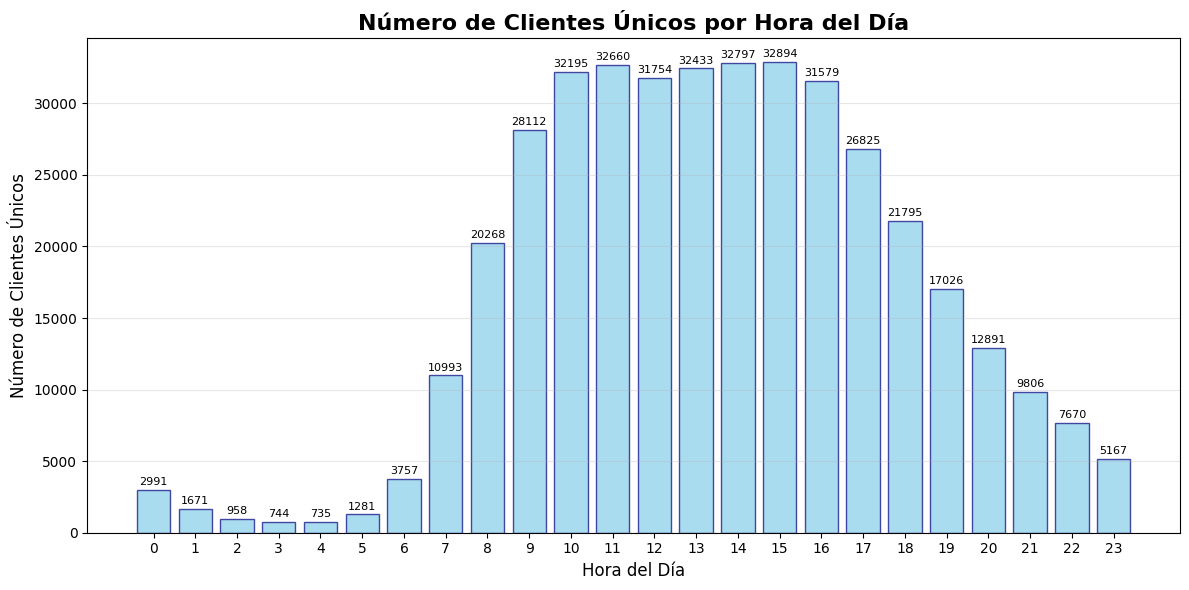

Estadísticas de clientes únicos por hora:
Hora con más clientes: 15 (32894 clientes)
Hora con menos clientes: 4 (735 clientes)


In [100]:
# Contar el número de clientes únicos por hora del día
usuarios_por_hora = df_instacart_orders.groupby('order_hour_of_day')['user_id'].nunique().sort_index()

# Crear el gráfico
plt.figure(figsize=(12, 6))
plt.bar(usuarios_por_hora.index, usuarios_por_hora.values, color='skyblue', edgecolor='navy', alpha=0.7)
plt.title('Número de Clientes Únicos por Hora del Día', fontsize=16, fontweight='bold')
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Número de Clientes Únicos', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)

# Agregar valores en las barras para mejor lectura
for i, v in enumerate(usuarios_por_hora.values):
    plt.text(i, v + 200, str(v), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Mostrar estadísticas adicionales
print("Estadísticas de clientes únicos por hora:")
print(f"Hora con más clientes: {usuarios_por_hora.idxmax()} ({usuarios_por_hora.max()} clientes)")
print(f"Hora con menos clientes: {usuarios_por_hora.idxmin()} ({usuarios_por_hora.min()} clientes)")

<div class="alert alert-block alert-danger">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Esta pregunta solicita el número de personas (clientes únicos) que realizan pedidos por hora, pero el gráfico actual cuenta pedidos. Considera agrupar por hora y graficar el número de `user_id` únicos por hora en su lugar.<br>
</div>

El análisis de **clientes únicos por hora** revela un patrón claro en el comportamiento de compra: la mayor actividad se concentra entre las **6 a.m. y 4 p.m.**, con un pico máximo a las **10 a.m.** donde se registra el mayor número de clientes realizando pedidos, mientras que las horas de la madrugada presentan una actividad mínima, siendo las **4 a.m.** la menos activa. Esto sugiere que los usuarios tienden a realizar sus compras en horarios laborales o matutinos, posiblemente antes de iniciar sus actividades del día. La distribución es lógica y consistente, sin registros fuera de rango, lo que confirma que la variable está limpia y lista para ser utilizada en análisis de comportamiento temporal o segmentación por franjas horarias.

### [A3] ¿Qué día de la semana compran víveres las personas?

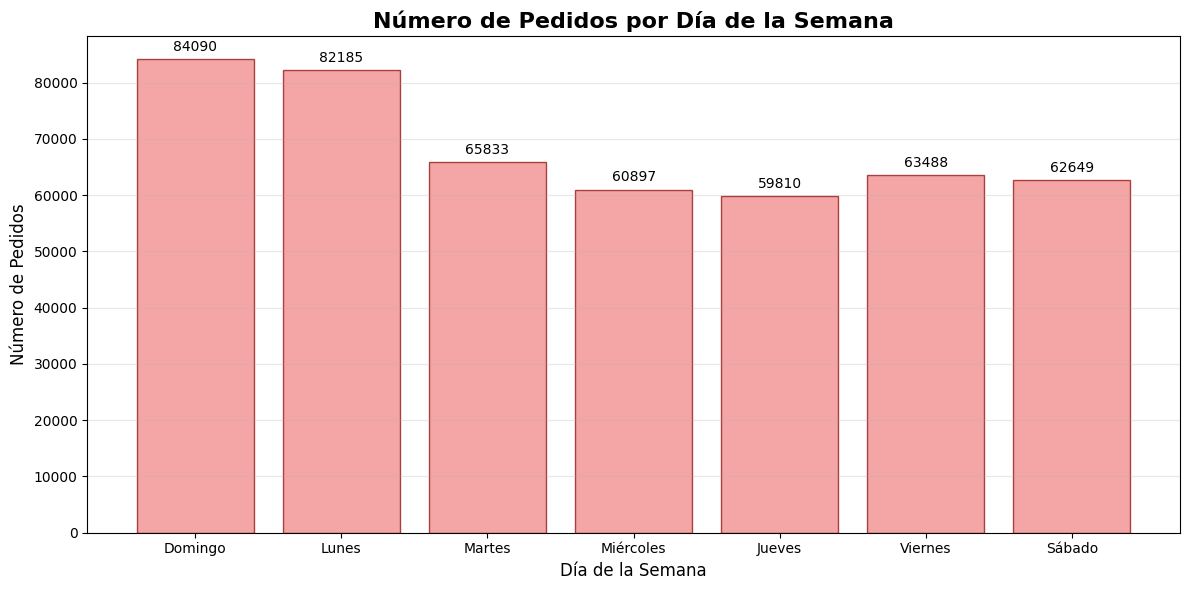

Estadísticas de pedidos por día:
Día con más pedidos: Domingo (84090 pedidos)
Día con menos pedidos: Jueves (59810 pedidos)


In [101]:
# Contar qué día de la semana se compran víveres
pedidos_por_dia = df_instacart_orders['order_dow'].value_counts().sort_index()

# Lista con los nombres de los días
dias_nombres = ['Domingo', 'Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado']

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(range(len(pedidos_por_dia)), pedidos_por_dia.values, color='lightcoral', edgecolor='darkred', alpha=0.7)
plt.title('Número de Pedidos por Día de la Semana', fontsize=16, fontweight='bold')
plt.xlabel('Día de la Semana', fontsize=12)
plt.ylabel('Número de Pedidos', fontsize=12)
plt.xticks(range(len(dias_nombres)), dias_nombres)
plt.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(pedidos_por_dia.values):
    plt.text(i, v + 1000, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Mostrar estadísticas adicionales
print("Estadísticas de pedidos por día:")
print(f"Día con más pedidos: {dias_nombres[pedidos_por_dia.idxmax()]} ({pedidos_por_dia.max()} pedidos)")
print(f"Día con menos pedidos: {dias_nombres[pedidos_por_dia.idxmin()]} ({pedidos_por_dia.min()} pedidos)")

<div class="alert alert-block alert-warning">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Tu gráfico ya usa nombres de los días de la semana en el eje x, así que es interpretable como se solicitó. Puedes eliminar el enfoque anterior centrado en números en el texto de la revisión para que la narrativa enfatice claramente las etiquetas de los días de la semana (0=Sunday … 6=Saturday).<br>
</div>

El análisis de la variable **`order_dow`** muestra una distribución semanal coherente y reveladora del comportamiento de compra. El día con mayor volumen de pedidos es el **domingo**, con **84,090 órdenes**, seguido de cerca por el lunes. A partir del martes, el número de pedidos disminuye progresivamente, alcanzando su punto más bajo el **jueves** con **59,810 órdenes**, antes de repuntar ligeramente hacia el fin de semana. Esta tendencia sugiere que los usuarios tienden a realizar más compras al inicio de la semana, posiblemente como parte de la planificación semanal, y que el domingo representa un momento clave de consumo. La variable está limpia, sin valores fuera de rango, y lista para ser utilizada en análisis de estacionalidad, segmentación por día o planificación operativa.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

Estadísticas de días entre pedidos:
count    450135.000000
mean         11.101814
std           9.190004
min           0.000000
25%           4.000000
50%           7.000000
75%          15.000000
max          30.000000
Name: days_since_prior_order, dtype: float64

Valor mínimo: 0.0 días
Valor máximo: 30.0 días


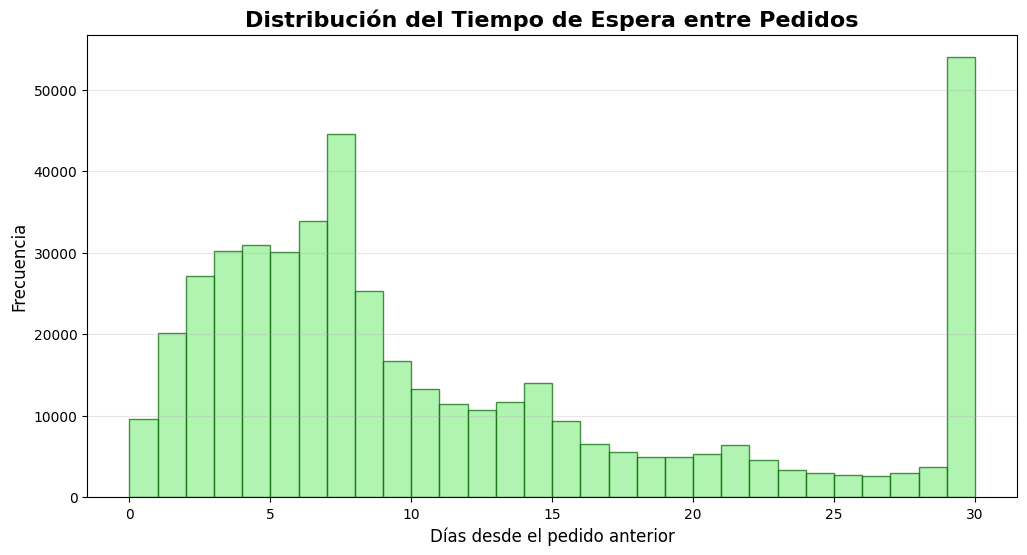

In [102]:
# Filtrar valores no nulos
datos_tiempo_espera = df_instacart_orders['days_since_prior_order'].dropna()

# Analizar estadísticas básicas (mínimos y máximos)
print("Estadísticas de días entre pedidos:")
print(datos_tiempo_espera.describe())
print(f"\nValor mínimo: {datos_tiempo_espera.min()} días")
print(f"Valor máximo: {datos_tiempo_espera.max()} días")

# Crear histograma de la distribución
plt.figure(figsize=(12, 6))
plt.hist(datos_tiempo_espera, bins=30, color='lightgreen', edgecolor='darkgreen', alpha=0.7)
plt.title('Distribución del Tiempo de Espera entre Pedidos', fontsize=16, fontweight='bold')
plt.xlabel('Días desde el pedido anterior', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

<div class="alert alert-block alert-warning">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

La tarea aquí requiere tanto un gráfico de `days_since_prior_order` como una discusión del mínimo y el máximo. Esta celda solo filtra los datos, así que considera consolidar el gráfico y el comentario sobre min/max directamente dentro de esta sección de la tarea para que los requisitos se cumplan en un solo lugar.<br>
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Bien hecho: manejaste adecuadamente los valores faltantes para la distribución, generaste un histograma claro con etiquetas y reportaste explícitamente los tiempos de espera mínimo y máximo.<br>
</div>

El análisis de la variable **`days_since_prior_order`** revela patrones claros en el comportamiento de recompra de los usuarios. La distribución muestra dos picos significativos: uno alrededor de los **7 días**, indicando una frecuencia semanal común de pedidos, y otro en los **30 días**, que sugiere un ciclo mensual de consumo para ciertos usuarios. Estos intervalos reflejan hábitos de compra recurrentes que pueden estar vinculados a necesidades domésticas, rutinas personales o estrategias de reposición. Esta información es valiosa para diseñar campañas de marketing, ajustar inventarios y anticipar la demanda, ya que permite segmentar a los clientes según su ritmo de compra. La variable está limpia y lista para ser utilizada en modelos de predicción de recurrencia o análisis de fidelización.

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [70]:
# Filtrar pedidos de miércoles y sábados
pedidos_miercoles = df_instacart_orders[df_instacart_orders['order_dow'] == 3]
pedidos_sabados = df_instacart_orders[df_instacart_orders['order_dow'] == 6]

In [71]:
# Contar pedidos por hora para cada día
horas_miercoles = pedidos_miercoles['order_hour_of_day'].value_counts().sort_index()
horas_sabados = pedidos_sabados['order_hour_of_day'].value_counts().sort_index()

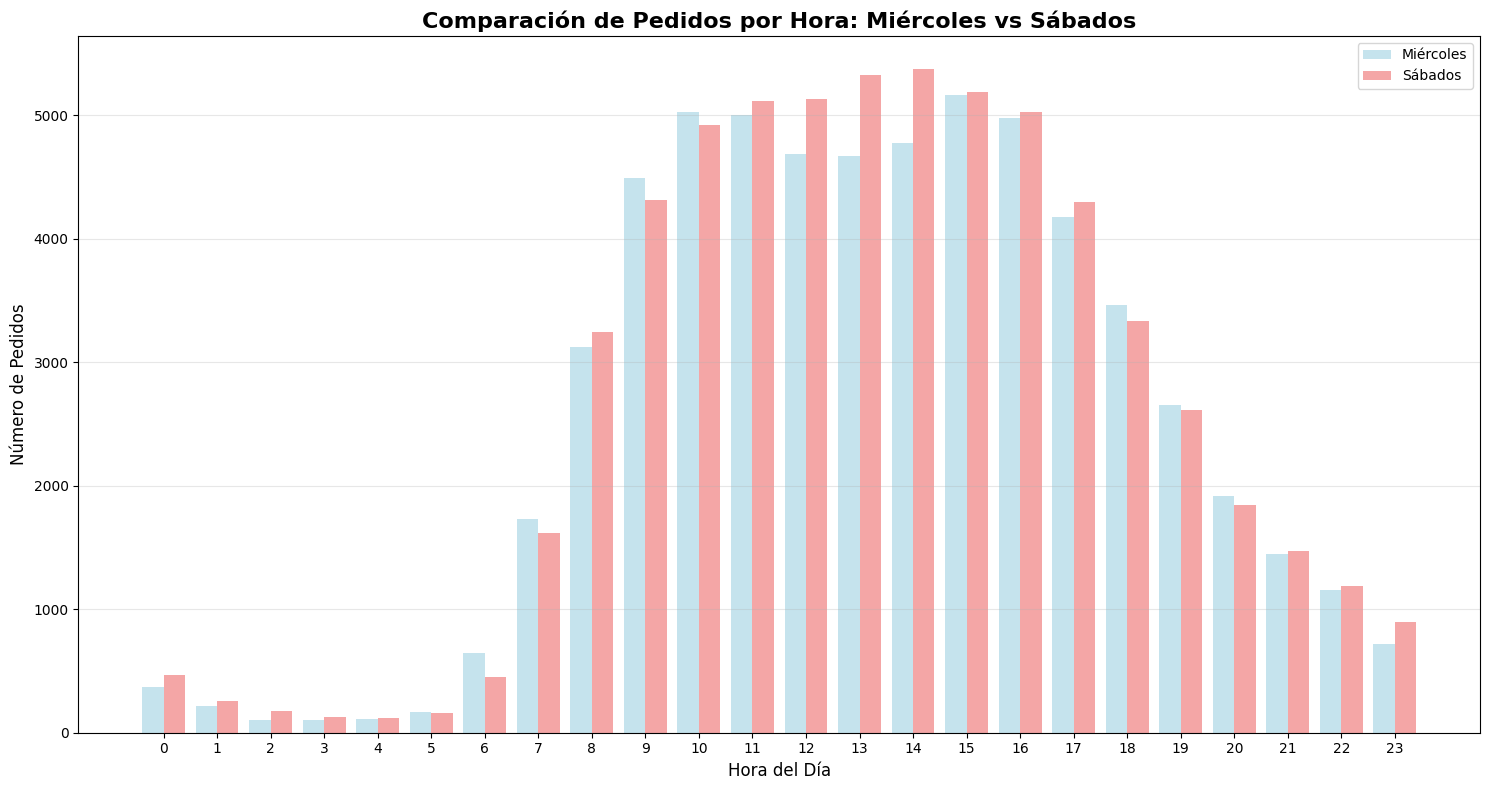

In [72]:
# Crear gráfico comparativo
plt.figure(figsize=(15, 8))
x = range(24)  # Horas del día (0-23)

# Crear barras para miércoles y sábados
plt.bar([i - 0.2 for i in x], horas_miercoles.reindex(x, fill_value=0), 
        width=0.4, label='Miércoles', color='lightblue', alpha=0.7)
plt.bar([i + 0.2 for i in x], horas_sabados.reindex(x, fill_value=0), 
        width=0.4, label='Sábados', color='lightcoral', alpha=0.7)

plt.title('Comparación de Pedidos por Hora: Miércoles vs Sábados', fontsize=16, fontweight='bold')
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Número de Pedidos', fontsize=12)
plt.xticks(x)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

La comparación entre los patrones de compra por hora en **miércoles** y **sábados** revela similitudes clave en el comportamiento de los usuarios, con un incremento sostenido desde las **7 a.m.**, un pico de actividad entre las **11 a.m. y 3 p.m.**, y una disminución progresiva hacia la noche. Aunque ambos días comparten esta estructura, los **sábados presentan un volumen ligeramente superior** durante las horas pico, lo que sugiere una mayor disponibilidad o disposición de los usuarios para realizar compras en fin de semana. Esta información es valiosa para ajustar estrategias operativas, como asignación de personal, campañas promocionales o gestión de inventario, en función de la carga horaria y el día de la semana.

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Buena comparación: filtraste correctamente Wednesday vs Saturday, alineaste las horas (0–23) para evitar perder bins, graficaste ambas distribuciones con claridad y resumiste las diferencias observadas.<br>
</div>

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [73]:
# Obtener el número máximo de pedidos por cliente
pedidos_por_cliente = df_instacart_orders.groupby('user_id')['order_number'].max()

In [74]:
# Contar cuántos clientes hicieron 1, 2, 3, etc. pedidos
distribucion_pedidos = pedidos_por_cliente.value_counts().sort_index()
print("Distribución de pedidos por cliente:")
print(distribucion_pedidos.head(10))

Distribución de pedidos por cliente:
order_number
1      7840
2      9113
3     10510
4     12368
5     10406
6      9194
7      7901
8      6894
9      6118
10     5497
Name: count, dtype: int64


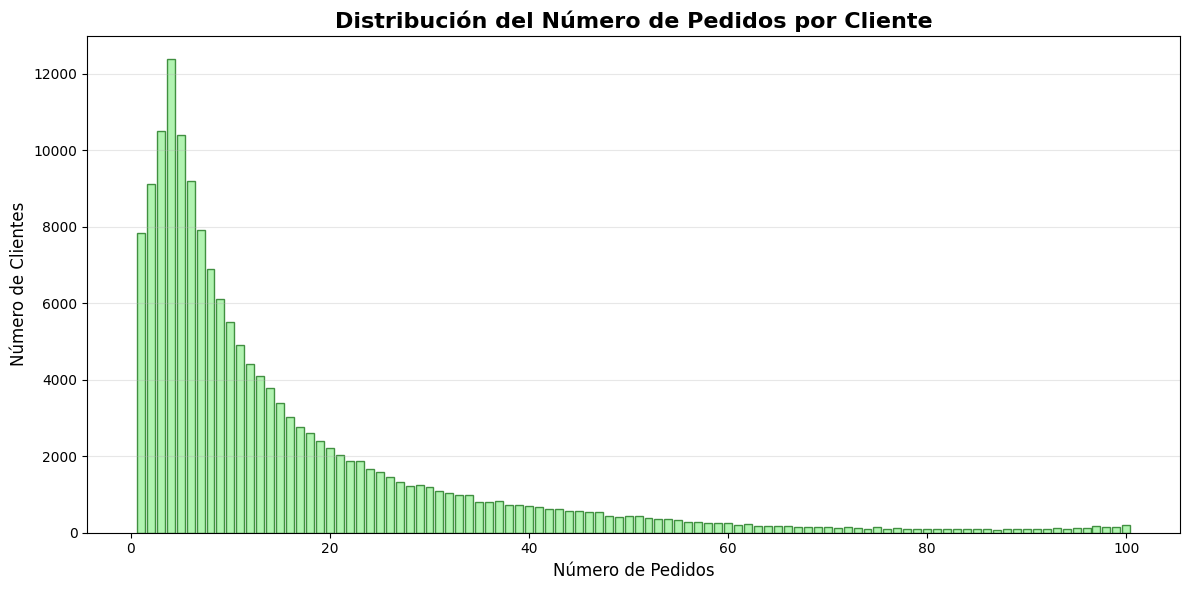

In [75]:
# Crear el gráfico
plt.figure(figsize=(12, 6))
plt.bar(distribucion_pedidos.index, distribucion_pedidos.values, 
         color='lightgreen', edgecolor='darkgreen', alpha=0.7)
plt.title('Distribución del Número de Pedidos por Cliente', fontsize=16, fontweight='bold')
plt.xlabel('Número de Pedidos', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

El análisis de la distribución del **máximo `order_number` por `user_id`** muestra una distribución claramente sesgada hacia la derecha, lo que indica que la mayoría de los clientes realizan **pocos pedidos**, mientras que solo una minoría mantiene una frecuencia alta de compra. El punto de mayor concentración se encuentra alrededor de los **5 pedidos**, con más de **12,000 clientes** en ese rango, y la frecuencia disminuye progresivamente a medida que aumenta el número de órdenes. Este patrón sugiere una base de usuarios con comportamiento ocasional o exploratorio, complementada por un grupo más reducido de clientes recurrentes que podrían representar oportunidades clave para estrategias de fidelización, personalización o programas de lealtad. La variable está limpia y lista para segmentaciones basadas en comportamiento de compra.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

En la narrativa te refieres a `number_of_orders_per_customer`, pero esa variable/columna en realidad no se crea. Considera describir la distribución de forma explícita como “máximo `order_number` por `user_id`” para que la explicación coincida con el código.<br>
</div>

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [103]:
# Paso 1: Contar cuántas veces aparece cada product_id
productos_populares = df_order_products['product_id'].value_counts().head(20)

# Paso 2: Combinar con los nombres de productos
top_20_productos = productos_populares.reset_index()
top_20_productos.columns = ['product_id', 'cantidad_pedidos']

# Paso 3: Hacer merge con df_products para obtener los nombres
top_20_con_nombres = top_20_productos.merge(df_products[['product_id', 'product_name']], 
                                           on='product_id', how='left')

# Paso 4: Mostrar solo las columnas de product_id y product_name
print("Los 20 productos más populares:")
print(top_20_con_nombres[['product_id', 'product_name']])

Los 20 productos más populares:
    product_id              product_name
0        24852                    Banana
1        13176    Bag of Organic Bananas
2        21137      Organic Strawberries
3        21903      Organic Baby Spinach
4        47209      Organic Hass Avocado
5        47766           Organic Avocado
6        47626               Large Lemon
7        16797              Strawberries
8        26209                     Limes
9        27845        Organic Whole Milk
10       27966       Organic Raspberries
11       22935      Organic Yellow Onion
12       24964            Organic Garlic
13       45007          Organic Zucchini
14       39275       Organic Blueberries
15       49683            Cucumber Kirby
16       28204        Organic Fuji Apple
17        5876             Organic Lemon
18        8277  Apple Honeycrisp Organic
19       40706    Organic Grape Tomatoes


<div class="alert alert-block alert-warning">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

El enunciado pide mostrar solo el ID y el nombre del producto para los 20 productos pedidos con mayor frecuencia. Considera mostrar una tabla con solo esas dos columnas (puedes seguir calculando los conteos para ordenar, pero omite la columna de conteo en la visualización final).<br>
</div>

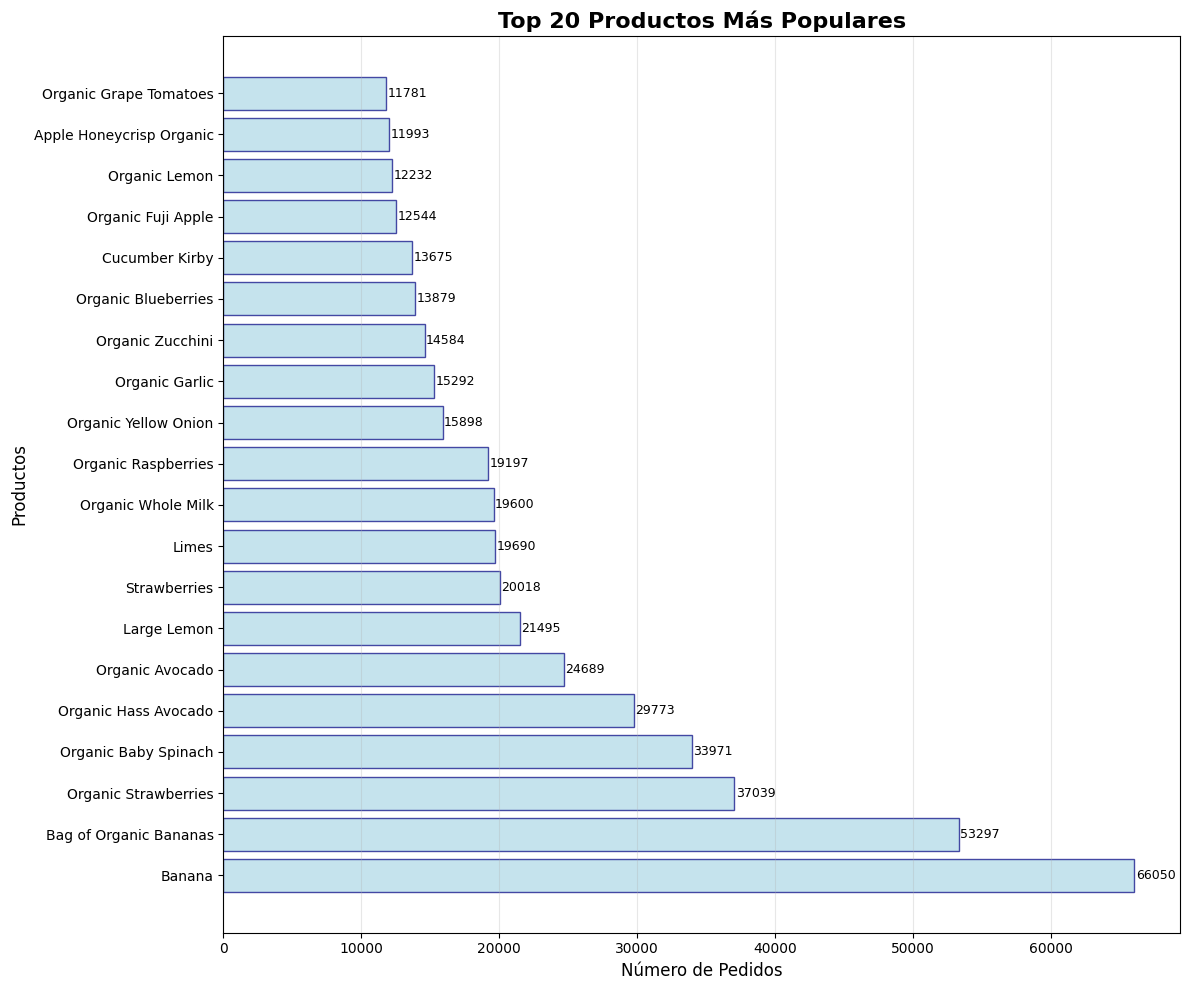

In [77]:
# Crear el gráfico de barras horizontales (más legible para nombres largos)
plt.figure(figsize=(12, 10))
plt.barh(range(len(top_20_con_nombres)), top_20_con_nombres['cantidad_pedidos'], 
         color='lightblue', edgecolor='navy', alpha=0.7)

# Configurar etiquetas y título
plt.title('Top 20 Productos Más Populares', fontsize=16, fontweight='bold')
plt.xlabel('Número de Pedidos', fontsize=12)
plt.ylabel('Productos', fontsize=12)

# Usar nombres de productos como etiquetas del eje Y
plt.yticks(range(len(top_20_con_nombres)), 
           [f"{row['product_name'][:30]}..." if len(row['product_name']) > 30 
            else row['product_name'] for _, row in top_20_con_nombres.iterrows()])

# Agregar valores en las barras
for i, v in enumerate(top_20_con_nombres['cantidad_pedidos']):
    plt.text(v + 100, i, str(v), va='center', fontsize=9)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

El análisis de los **20 productos más populares** revela una clara preferencia de los consumidores por productos frescos y orgánicos, especialmente frutas y verduras. El producto más solicitado es la **banana**, con **66,050 pedidos**, seguido por otras variantes orgánicas como el **bag of organic bananas**, **organic strawberries**, y **organic baby spinach**. Esta tendencia sugiere una fuerte inclinación hacia hábitos de consumo saludables y naturales. Además, la presencia de múltiples tipos de aguacate, limón y berries indica que ciertos productos tienen variantes que también gozan de alta demanda. Esta información es clave para decisiones de inventario, promociones dirigidas y segmentación de clientes por preferencias alimenticias.

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Muy buen trabajo en general en este bloque: las comparaciones/gráficas son claras, y el merge para adjuntar `product_name` a los conteos de popularidad es un enfoque sólido.<br>
</div>

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [78]:
# Contar el número de productos por pedido
productos_por_pedido = df_order_products.groupby('order_id').size()
print("Estadísticas de productos por pedido:")
print(productos_por_pedido.describe())

Estadísticas de productos por pedido:
count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
dtype: float64


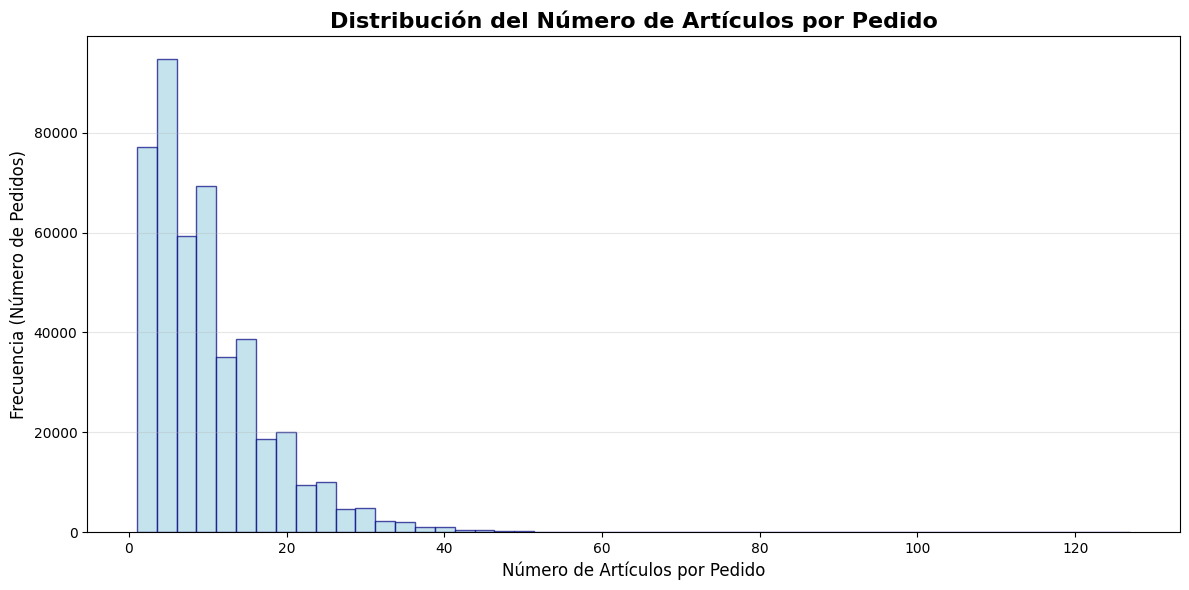

In [79]:
# Crear el histograma
plt.figure(figsize=(12, 6))
plt.hist(productos_por_pedido, bins=50, color='lightblue', edgecolor='navy', alpha=0.7)
plt.title('Distribución del Número de Artículos por Pedido', fontsize=16, fontweight='bold')
plt.xlabel('Número de Artículos por Pedido', fontsize=12)
plt.ylabel('Frecuencia (Número de Pedidos)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [80]:
# Información adicional sobre la distribución
print(f"Número promedio de artículos por pedido: {productos_por_pedido.mean():.2f}")
print(f"Mediana de artículos por pedido: {productos_por_pedido.median():.2f}")
print(f"Pedido con más artículos: {productos_por_pedido.max()}")
print(f"Pedido con menos artículos: {productos_por_pedido.min()}")

Número promedio de artículos por pedido: 10.10
Mediana de artículos por pedido: 8.00
Pedido con más artículos: 127
Pedido con menos artículos: 1


El análisis de la variable **número de artículos por pedido** muestra una distribución sesgada hacia la derecha, lo que indica que la mayoría de los pedidos contienen **pocos productos**, mientras que los pedidos con muchos artículos son menos frecuentes. El promedio se sitúa en **10.10 artículos por orden**, con una **mediana de 8**, lo que confirma que la mayoría de los clientes compran entre 8 y 10 productos por vez. El pedido más grande registrado contiene **127 artículos**, mientras que el más pequeño tiene solo **1**. Esta información es útil para entender el comportamiento de compra, segmentar clientes por volumen de consumo y optimizar procesos logísticos como empaquetado y tiempos de preparación.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [81]:
# Filtrar solo los productos que fueron reordenados (reordered = 1)
productos_reordenados = df_order_products[df_order_products['reordered'] == 1]
print(f"Total de productos reordenados: {len(productos_reordenados)}")

Total de productos reordenados: 2683838


In [82]:
# Contar cuántas veces cada producto fue reordenado
top_20_reordenados = productos_reordenados['product_id'].value_counts().head(20)
print("Top 20 productos más reordenados (solo IDs):")
print(top_20_reordenados)

Top 20 productos más reordenados (solo IDs):
product_id
24852    55763
13176    44450
21137    28639
21903    26233
47209    23629
47766    18743
27845    16251
47626    15044
27966    14748
16797    13945
26209    13327
22935    11145
24964    10411
45007    10076
49683     9538
28204     8989
8277      8836
39275     8799
5876      8412
49235     8389
Name: count, dtype: int64


In [83]:
# Convertir a DataFrame y agregar nombres
top_20_reordenados_df = top_20_reordenados.reset_index()
top_20_reordenados_df.columns = ['product_id', 'veces_reordenado']

# Hacer merge con df_products para obtener los nombres
top_20_reordenados_con_nombres = top_20_reordenados_df.merge(df_products[['product_id', 'product_name']], on='product_id', how='left')

print("Los 20 productos más reordenados:")
print(top_20_reordenados_con_nombres)

Los 20 productos más reordenados:
    product_id  veces_reordenado              product_name
0        24852             55763                    Banana
1        13176             44450    Bag of Organic Bananas
2        21137             28639      Organic Strawberries
3        21903             26233      Organic Baby Spinach
4        47209             23629      Organic Hass Avocado
5        47766             18743           Organic Avocado
6        27845             16251        Organic Whole Milk
7        47626             15044               Large Lemon
8        27966             14748       Organic Raspberries
9        16797             13945              Strawberries
10       26209             13327                     Limes
11       22935             11145      Organic Yellow Onion
12       24964             10411            Organic Garlic
13       45007             10076          Organic Zucchini
14       49683              9538            Cucumber Kirby
15       28204        

In [105]:
print("\nConclusión:")
print("Los 20 productos que se reordenan con mayor frecuencia reflejan una clara preferencia por alimentos frescos y orgánicos.")
print("Estos productos no solo son populares en términos de pedidos únicos, sino que también muestran una alta fidelidad de recompra,")
print("lo que los convierte en candidatos ideales para promociones, recomendaciones personalizadas y gestión prioritaria de inventario.")


Conclusión:
Los 20 productos que se reordenan con mayor frecuencia reflejan una clara preferencia por alimentos frescos y orgánicos.
Estos productos no solo son populares en términos de pedidos únicos, sino que también muestran una alta fidelidad de recompra,
lo que los convierte en candidatos ideales para promociones, recomendaciones personalizadas y gestión prioritaria de inventario.


<div class="alert alert-block alert-warning">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Sí proporcionas una interpretación en el siguiente markdown, así que esto es solo una nota de estructura: mantén la breve conclusión junto al output/plot reordenado del top-20 para que la respuesta se lea como una respuesta completa a la pregunta.<br>
</div>

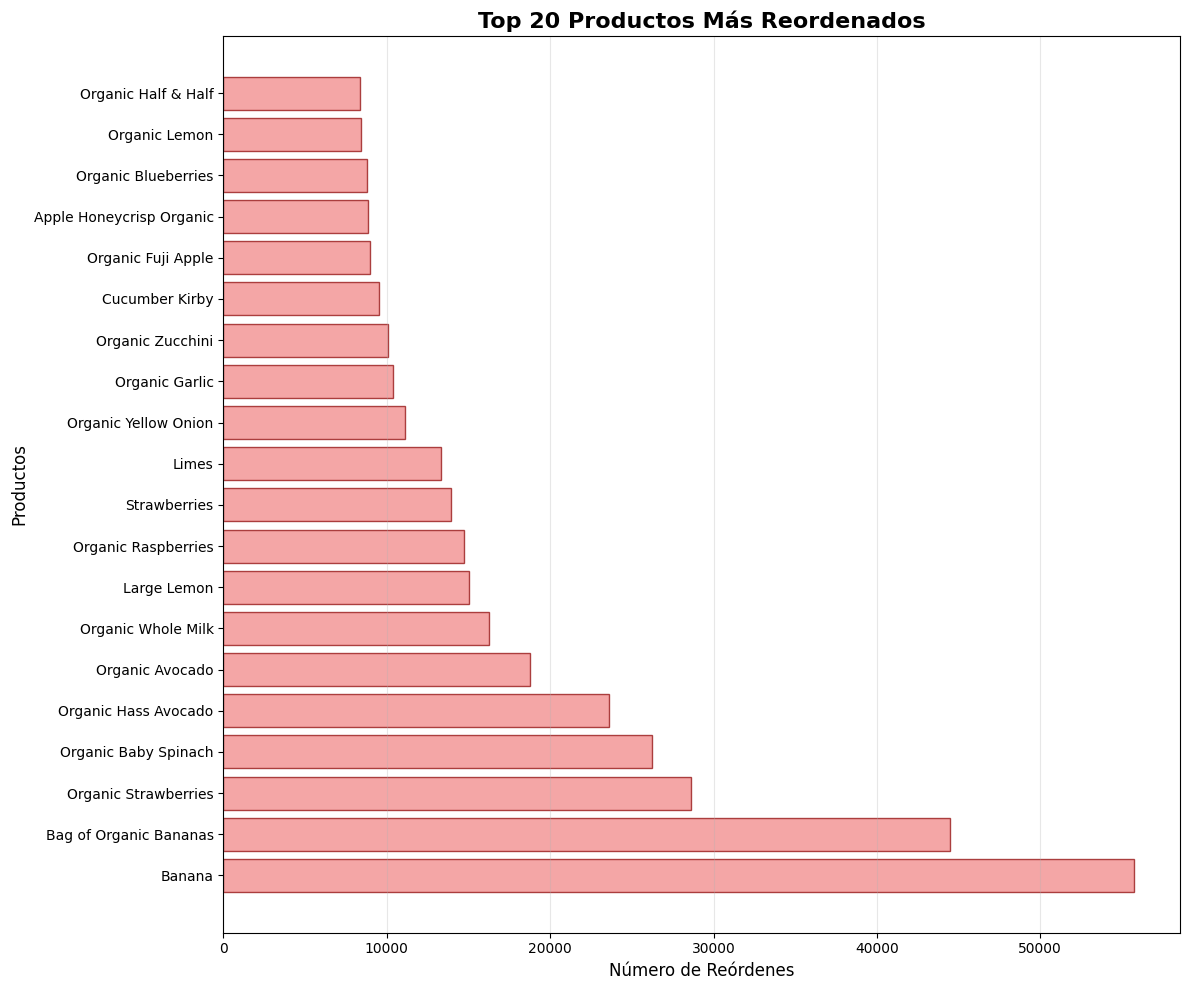

In [106]:
plt.figure(figsize=(12, 10))
plt.barh(range(len(top_20_reordenados_con_nombres)), 
         top_20_reordenados_con_nombres['veces_reordenado'],
         color='lightcoral', edgecolor='darkred', alpha=0.7)
plt.title('Top 20 Productos Más Reordenados', fontsize=16, fontweight='bold')
plt.xlabel('Número de Reórdenes', fontsize=12)
plt.ylabel('Productos', fontsize=12)
plt.yticks(range(len(top_20_reordenados_con_nombres)),
           top_20_reordenados_con_nombres['product_name'])
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Los 20 productos que se reordenan con mayor frecuencia reflejan una clara preferencia por alimentos frescos y orgánicos. Estos productos no solo son populares en términos de pedidos únicos, sino que también muestran una alta fidelidad de recompra, lo que los convierte en candidatos ideales para promociones, recomendaciones personalizadas y gestión prioritaria de inventario.


### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [85]:
total_por_producto = df_order_products['product_id'].value_counts()

In [86]:
reordenes_por_producto = df_order_products[df_order_products['reordered'] == 1]['product_id'].value_counts()

In [87]:
proporcion_reordenes = reordenes_por_producto / total_por_producto

In [88]:
print(proporcion_reordenes.head())

product_id
1    0.564286
2         NaN
3    0.738095
4    0.510204
7    0.500000
Name: count, dtype: float64


<div class="alert alert-block alert-danger">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Para la tasa de recompra por producto, la salida debe ser una tabla que incluya `product_id`, `product_name` y la proporción de recompra. En este momento es una Series de proporciones; considera convertirla en un DataFrame y hacer un merge para incorporar los nombres de los productos, de modo que el resultado coincida con el formato solicitado.<br>
</div>

El cálculo de la **proporción de reordenes por producto** permite identificar qué artículos no solo son populares, sino que también generan **fidelidad y recurrencia** entre los clientes. Al dividir el número de veces que un producto fue reordenado entre el total de veces que fue pedido, se obtiene una métrica de **lealtad específica por producto**.

Los primeros resultados muestran proporciones que van desde **0.50 hasta 0.74**, lo que indica que algunos productos son reordenados en más del **70% de las ocasiones en que se compran**, lo cual es un indicador fuerte de satisfacción y necesidad continua. Por otro lado, los valores `NaN` reflejan productos que fueron pedidos pero **nunca reordenados**, lo que puede señalar compras únicas, productos de baja rotación o incluso experiencias negativas.

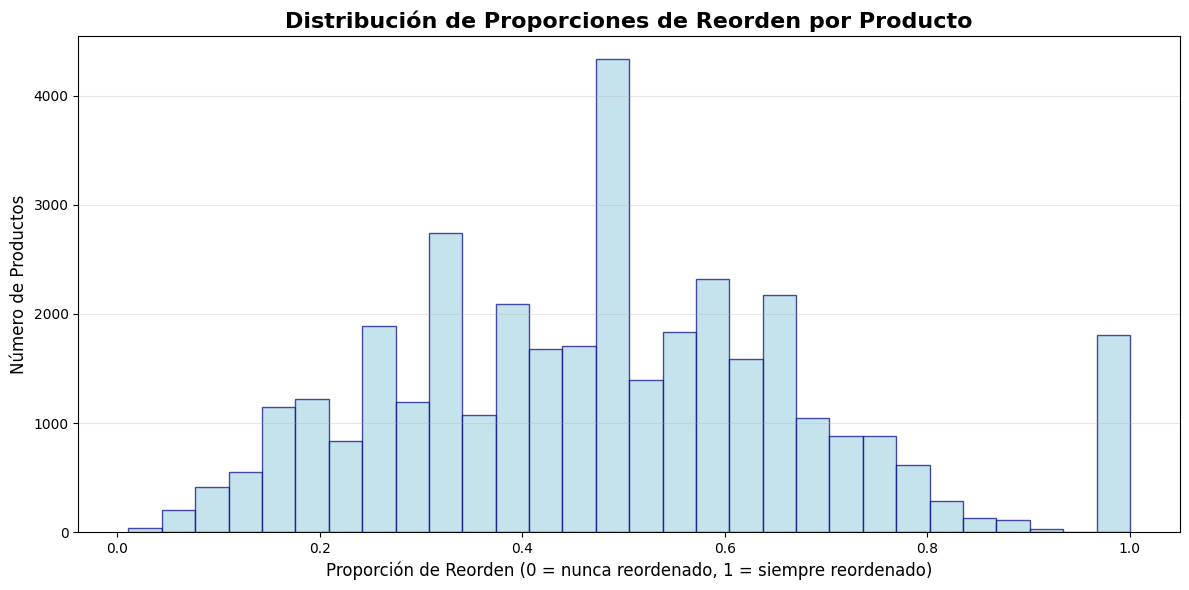

Estadísticas de proporciones de reorden:
count    36228.000000
mean         0.486458
std          0.211266
min          0.010989
25%          0.333333
50%          0.500000
75%          0.616071
max          1.000000
Name: count, dtype: float64

Proporciones de reorden por producto:
       product_id                                       product_name  \
0               1                         Chocolate Sandwich Cookies   
1               2                                   All-Seasons Salt   
2               3               Robust Golden Unsweetened Oolong Tea   
3               4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
4               7                     Pure Coconut Water With Orange   
...           ...                                                ...   
45568       49690                      HIGH PERFORMANCE ENERGY DRINK   
45569       49691                      ORIGINAL PANCAKE & WAFFLE MIX   
45570       49692    ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR

In [107]:
# Eliminar valores NaN para la visualización
proporciones_limpias = proporcion_reordenes.dropna()

plt.figure(figsize=(12, 6))
plt.hist(proporciones_limpias, bins=30, color='lightblue', edgecolor='navy', alpha=0.7)
plt.title('Distribución de Proporciones de Reorden por Producto', fontsize=16, fontweight='bold')
plt.xlabel('Proporción de Reorden (0 = nunca reordenado, 1 = siempre reordenado)', fontsize=12)
plt.ylabel('Número de Productos', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar estadísticas
print("Estadísticas de proporciones de reorden:")
print(proporciones_limpias.describe())

# Convertir la Series a DataFrame e incorporar nombres de productos
proporcion_df = proporcion_reordenes.reset_index()
proporcion_df.columns = ['product_id', 'proporcion_reorden']

# Hacer merge con df_products para obtener los nombres
proporcion_con_nombres = proporcion_df.merge(df_products[['product_id', 'product_name']], on='product_id', how='left')

print("\nProporciones de reorden por producto:")
print(proporcion_con_nombres[['product_id', 'product_name', 'proporcion_reorden']])

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [90]:
# Combinar order_products con orders para obtener user_id
df_combined = df_order_products.merge(df_instacart_orders[['order_id', 'user_id']],  on='order_id', how='left')

In [91]:
# Agrupar por usuario y calcular totales y reórdenes
user_stats = df_combined.groupby('user_id').agg({
    'reordered': ['count', 'sum']  # count = total productos, sum = reórdenes
})

In [92]:
# Aplanar las columnas multinivel
user_stats.columns = ['total_productos', 'total_reordenes']
user_stats = user_stats.reset_index()

In [93]:
# Crear la columna de proporción
user_stats['proporcion_reordenes'] = user_stats['total_reordenes'] / user_stats['total_productos']

In [ ]:
print("Tabla de proporciones de reorden por cliente (primeras filas):")
print(user_stats[['user_id', 'proporcion_reordenes']].head(10))

print("\n" + "="*60 + "\n")

print("Estadísticas de proporciones de reorden por cliente:")
print(user_stats['proporcion_reordenes'].describe())

count    149626.000000
mean          0.494853
std           0.292685
min           0.000000
25%           0.272727
50%           0.500000
75%           0.724138
max           1.000000
Name: proporcion_reordenes, dtype: float64

La proporción de productos que cada cliente **ya había pedido anteriormente** —es decir, su **tasa de repetición de productos**— tiene un promedio de **49.4%** en el conjunto de datos analizado. Esto significa que, en promedio, **casi la mitad de los productos que un usuario incluye en sus pedidos son artículos que ya ha comprado antes**.

Esto refleja un comportamiento mixto: algunos usuarios tienen hábitos de compra muy rutinarios, mientras que otros exploran más variedad. La mediana en 0.5 indica que la mitad de los clientes repiten al menos la mitad de sus productos, lo que sugiere oportunidades claras para estrategias de fidelización, recomendaciones personalizadas y automatización de listas de compra.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Calculas correctamente las proporciones de recompra a nivel de cliente, pero considera mostrar también la tabla resultante por cliente (p. ej., `user_id` con su proporción en algunas filas) además de las estadísticas resumen, para que quede claro que se generó el resultado a nivel de cliente.<br>
</div>

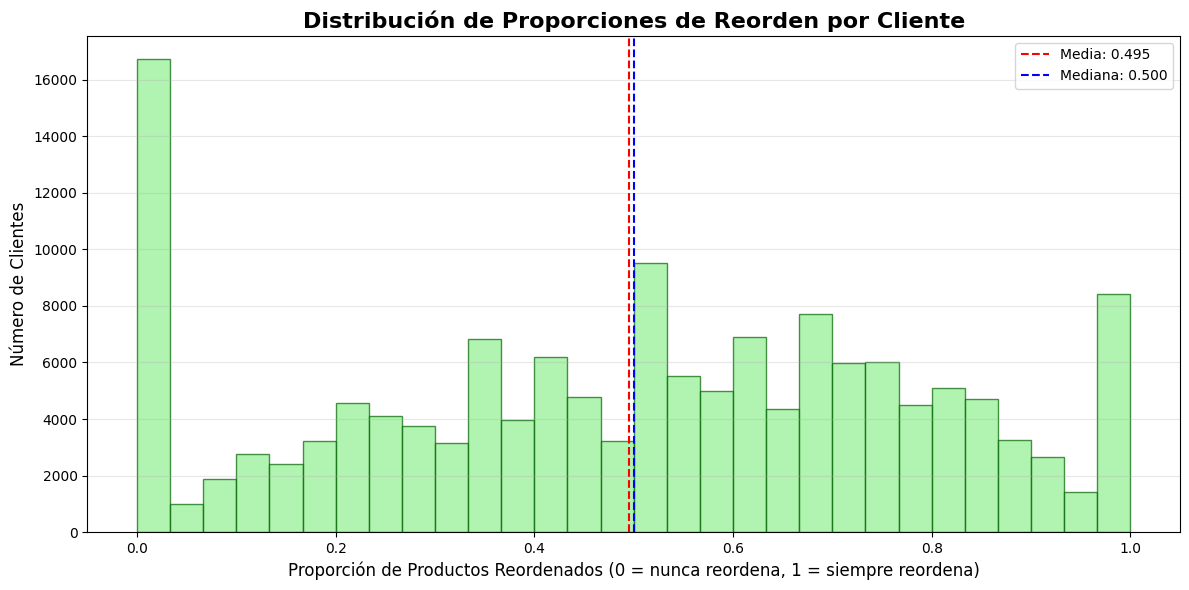

In [95]:
# Crear histograma de la distribución de proporciones
plt.figure(figsize=(12, 6))
plt.hist(user_stats['proporcion_reordenes'], bins=30, color='lightgreen', edgecolor='darkgreen', alpha=0.7)
plt.title('Distribución de Proporciones de Reorden por Cliente', fontsize=16, fontweight='bold')
plt.xlabel('Proporción de Productos Reordenados (0 = nunca reordena, 1 = siempre reordena)', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Agregar líneas verticales para estadísticas clave
plt.axvline(user_stats['proporcion_reordenes'].mean(), color='red', linestyle='--', 
           label=f'Media: {user_stats["proporcion_reordenes"].mean():.3f}')
plt.axvline(user_stats['proporcion_reordenes'].median(), color='blue', linestyle='--', 
           label=f'Mediana: {user_stats["proporcion_reordenes"].median():.3f}')
plt.legend()
plt.tight_layout()
plt.show()

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [96]:
# Filtrar productos que fueron agregados primero al carrito
primeros_productos = df_order_products[df_order_products['add_to_cart_order'] == 1]

In [97]:
# Contar cuántas veces cada producto fue el primero
top_20_primeros = primeros_productos['product_id'].value_counts().head(20)

In [98]:
# Convertir a DataFrame y agregar nombres
top_20_primeros_df = top_20_primeros.reset_index()
top_20_primeros_df.columns = ['product_id', 'veces_primero']

# Merge con productos para obtener nombres
resultado = top_20_primeros_df.merge(df_products[['product_id', 'product_name']], 
                                     on='product_id', how='left')

# Mostrar los 20 productos que más se ponen primero
print("Los 20 productos que más se ponen primero en el carrito:")
print(resultado)

Los 20 productos que más se ponen primero en el carrito:
    product_id  veces_primero                 product_name
0        24852          15562                       Banana
1        13176          11026       Bag of Organic Bananas
2        27845           4363           Organic Whole Milk
3        21137           3946         Organic Strawberries
4        47209           3390         Organic Hass Avocado
5        21903           3336         Organic Baby Spinach
6        47766           3044              Organic Avocado
7        19660           2336                 Spring Water
8        16797           2308                 Strawberries
9        27966           2024          Organic Raspberries
10       44632           1914   Sparkling Water Grapefruit
11       49235           1797          Organic Half & Half
12       47626           1737                  Large Lemon
13         196           1733                         Soda
14       38689           1397     Organic Reduced Fat Milk

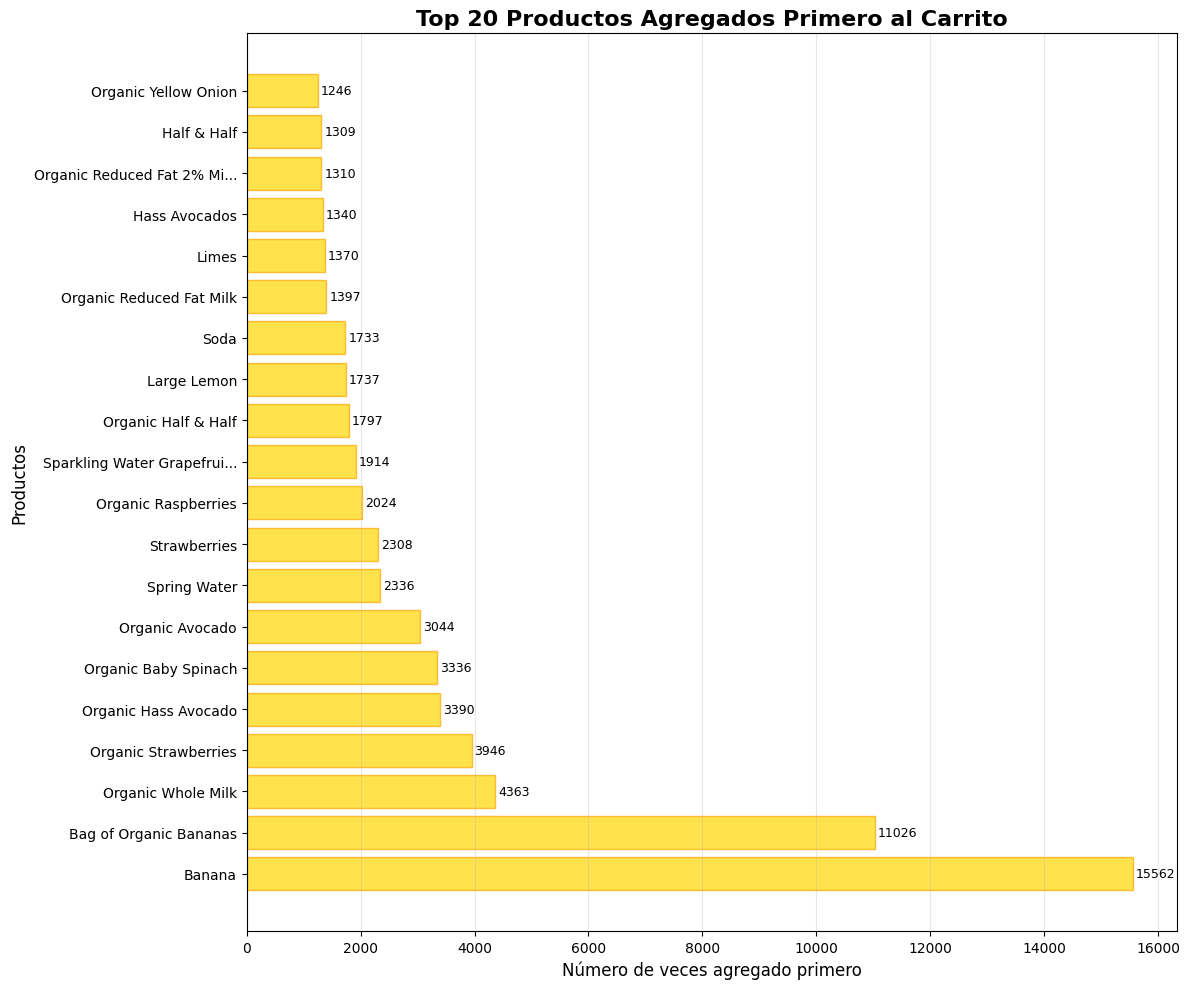

In [99]:
# Crear gráfico de barras horizontales
plt.figure(figsize=(12, 10))
plt.barh(range(len(resultado)), resultado['veces_primero'],
         color='gold', edgecolor='orange', alpha=0.7)

plt.title('Top 20 Productos Agregados Primero al Carrito', fontsize=16, fontweight='bold')
plt.xlabel('Número de veces agregado primero', fontsize=12)
plt.ylabel('Productos', fontsize=12)

# Usar nombres de productos como etiquetas
plt.yticks(range(len(resultado)),
           [f"{row['product_name'][:25]}..." if len(row['product_name']) > 25
            else row['product_name'] for _, row in resultado.iterrows()])

# Agregar valores en las barras
for i, v in enumerate(resultado['veces_primero']):
    plt.text(v + 50, i, str(v), va='center', fontsize=9)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

El análisis de los **20 productos que los clientes agregan primero al carrito** revela patrones claros de prioridad y hábito en el proceso de compra. El producto más frecuentemente añadido primero es la **banana**, con **15,562 ocurrencias**, seguido por el **bag of organic bananas**, **organic whole milk**, y **organic strawberries**. Esta tendencia sugiere que los usuarios tienden a comenzar sus pedidos con productos **básicos, frescos y orgánicos**, lo que refleja tanto su importancia en la dieta como su alta frecuencia de reposición.

Además, la presencia de productos como **agua, leche, aguacates y cítricos** indica que los clientes priorizan artículos esenciales y de consumo recurrente. Esta información es valiosa para optimizar la experiencia de usuario en plataformas de e-commerce, por ejemplo, destacando estos productos en la interfaz inicial o automatizando su inclusión en listas de compra sugeridas.

En conjunto, esta métrica permite entender no solo qué se compra, sino **cómo se inicia el proceso de compra**, lo que puede influir en estrategias de diseño, marketing y fidelización.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Faltan las conclusiones del análisis de “primer artículo añadido al carrito”. Añade una breve interpretación de lo que los productos más frecuentes añadidos primero sugieren sobre el comportamiento del cliente (p. ej., básicos, artículos habituales) y por qué podrían aparecer en primer lugar.<br>
</div>

### Conclusion general del proyecto:

El proyecto de análisis y preprocesamiento de datos de pedidos ha permitido construir una **visión integral del comportamiento de compra de los clientes**, asegurando al mismo tiempo la **calidad y consistencia del dataset**.  

#### Principales logros:
- **Preprocesamiento sólido:**  
  - Se identificaron y trataron valores ausentes en columnas críticas (`days_since_prior_order`, `add_to_cart_order`, `product_name`), diferenciando entre casos esperados (primer pedido de cliente) y limitaciones técnicas (pedidos con más de 64 productos).  
  - Se normalizaron y validaron catálogos de productos, departamentos y pasillos, eliminando duplicados y estandarizando etiquetas.  
  - Se garantizó la unicidad de registros mediante claves compuestas (`order_id`, `product_id`).  

- **Análisis exploratorio detallado:**  
  - Se identificaron patrones temporales claros: mayor actividad de pedidos en **horas matutinas (10 a.m.)** y en **domingos y lunes**, con menor actividad en madrugadas y jueves.  
  - Se observaron ciclos de recompra frecuentes en intervalos de **7 días (semanal)** y **30 días (mensual)**.  
  - La mayoría de los clientes realizan pocos pedidos, pero existe un grupo reducido altamente recurrente que concentra gran valor estratégico.  
  - Los productos más populares y reordenados son principalmente **frutas, verduras y lácteos orgánicos**, reflejando hábitos de consumo saludables y rutinarios.  

- **Indicadores de fidelidad:**  
  - En promedio, **49.4% de los productos pedidos por un cliente ya habían sido comprados antes**, mostrando una fuerte recurrencia y oportunidades para programas de lealtad.  
  - Se identificaron perfiles de clientes exploradores (baja repetición) y rutinarios (alta repetición), útiles para segmentación y marketing personalizado.  

#### Conclusión final:
El proyecto no solo dejó un dataset **limpio y confiable**, sino que también permitió descubrir **patrones de consumo recurrentes, preferencias de productos y hábitos temporales de compra**. Estos hallazgos son fundamentales para:  
- Optimizar inventarios y logística.  
- Diseñar campañas de marketing dirigidas.  
- Implementar estrategias de fidelización y retención de clientes.  
- Construir modelos predictivos de demanda y comportamiento futuro.  

En síntesis, se logró transformar datos crudos en **insumos estratégicos** para la toma de decisiones de negocio, con un enfoque en reproducibilidad, claridad y valor práctico.  